# Week 7: Feature Selection Methods

## Learning Objectives

By the end of this week, you will:

1. **Understand why feature selection matters** — Fewer, better features often outperform using all features
2. **Apply Lasso regression** — L1 penalty that shrinks unimportant coefficients to exactly zero
3. **Apply Elastic Net** — Combines Lasso (L1) and Ridge (L2) penalties for more stable selection
4. **Use MRMR** — A filter method that picks features with high relevance and low redundancy
5. **Rank features with Random Forest** — Tree-based feature importance scores
6. **Compare selection methods** — Observe how different methods pick different subsets
7. **Kaggle Challenge** — Use feature selection + your best model to maximize test accuracy

In [40]:
import numpy as np 
import pandas as pd 

df = pd.read_csv('./heart_failure_clinical_records_dataset.csv') #make sure to replace with your data directory
df.drop(columns=['time'],inplace=True) #drop the time column which is not one of the informative features 
df_features = df.iloc[:,:-1]
df_target = df['DEATH_EVENT']

X = df_features
y = df_target

In [41]:
X

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0
...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,1,38,1,155000.00,1.1,143,1,1
295,55.0,0,1820,0,38,0,270000.00,1.2,139,0,0
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0
297,45.0,0,2413,0,38,0,140000.00,1.4,140,1,1


In [42]:
y.value_counts(normalize=True)

DEATH_EVENT
0    0.67893
1    0.32107
Name: proportion, dtype: float64

## Train / Test Split

We split data **before** any feature selection. This is critical:

- Feature selection must only see training data — otherwise we leak test information
- `stratify=y` ensures both splits have the same class ratio (~68% survived, ~32% died)
- `random_state=42` makes results reproducible

In [43]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3,stratify=y,random_state=42)

In [44]:
print('X train shape: ',X_train.shape)
print('y train shape: ',y_train.shape)
print('X test shape: ',X_test.shape)
print('y test shape: ',y_test.shape)
print('y train: ',y_train.value_counts(normalize=True))
print('y test: ',y_test.value_counts(normalize=True))

X train shape:  (209, 11)
y train shape:  (209,)
X test shape:  (90, 11)
y test shape:  (90,)
y train:  DEATH_EVENT
0    0.679426
1    0.320574
Name: proportion, dtype: float64
y test:  DEATH_EVENT
0    0.677778
1    0.322222
Name: proportion, dtype: float64


In [45]:
feature_names = X.columns
feature_names

Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'platelets',
       'serum_creatinine', 'serum_sodium', 'sex', 'smoking'],
      dtype='str')

## Normalize Data

**Why normalize before Lasso/Elastic Net?**

Lasso and Elastic Net use coefficient magnitudes to decide which features to drop. If features are on different scales (e.g., `platelets` ≈ 200,000 vs `age` ≈ 60), large-scale features will dominate unfairly.

`StandardScaler` transforms each feature to **mean = 0, std = 1**, so all features compete on equal footing.

> **Rule:** Always fit the scaler on training data only (`fit_transform`), then apply to test data (`transform`). Fitting on test data would leak information.

In [46]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Why Feature Selection?

With 11 features and only 299 patients, some features are:
- **Irrelevant** — no real relationship with death (e.g., `sex`, `smoking` in this dataset)
- **Redundant** — highly correlated with another feature (adds noise, not information)

**Benefits of removing these features:**
- Reduces overfitting (model learns noise from irrelevant features)
- Faster training and inference
- More interpretable models

We will compare three types of feature selection methods:

| Type | Method | How it selects |
|------|--------|----------------|
| **Embedded** | Lasso | Penalizes coefficients during model training |
| **Embedded** | Elastic Net | Like Lasso but with added Ridge stability |
| **Filter** | MRMR | Statistical score — relevance minus redundancy |
| **Embedded** | Random Forest | Feature importance from tree splits |

## Lasso Feature Selection

**How it works:**

Lasso (Least Absolute Shrinkage and Selection Operator) fits a linear model with an L1 penalty:

$$\text{Loss} = \text{MSE} + \alpha \sum |\beta_i|$$

The penalty pushes small coefficients **exactly to zero**, effectively removing those features.

- **α (alpha)** controls the strength of the penalty — larger α = more features dropped
- `LassoCV` automatically finds the best α using 5-fold cross-validation

**Why it works for feature selection:**

Unlike Ridge (L2 penalty, which shrinks but never zeros), L1 creates **sparse solutions** — perfect for identifying which features to keep.

**Two thresholds below:**
- `B2 != 0` — any feature Lasso decided to keep at all
- `abs(B2) >= 0.02` — only features with meaningful coefficient size (stricter)

In [47]:
from sklearn import linear_model
model = linear_model.LassoCV(cv=5)
lasso_regression = model.fit(X_train,y_train)
B2 = lasso_regression.coef_
B2


array([ 0.0409842 ,  0.0155569 ,  0.0435928 ,  0.01277368, -0.10970532,
        0.01432047, -0.        ,  0.12604567, -0.01690006,  0.        ,
        0.        ])

In [48]:
selected_features = feature_names[B2 != 0]
selected_features
#selected_features = X.columns[abs(B2) >= 0.03]

Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'serum_creatinine',
       'serum_sodium'],
      dtype='str')

In [49]:
selected_features = feature_names[abs(B2) >= 0.02]
selected_features

Index(['age', 'creatinine_phosphokinase', 'ejection_fraction',
       'serum_creatinine'],
      dtype='str')

## Elastic Net Feature Selection

**How it works:**

Elastic Net combines both L1 (Lasso) and L2 (Ridge) penalties:

$$\text{Loss} = \text{MSE} + \left[ \rho \sum |\beta_i| + (1-\rho) \sum \beta_i^2 \right]$$

- `l1_ratio` (ρ) = 0.5 means equal weight on L1 and L2
- L1 part: drives some coefficients to zero (selection)
- L2 part: stabilizes correlated features (Ridge keeps them together rather than randomly dropping one)

**Why use Elastic Net over Lasso?**

| Situation | Lasso | Elastic Net |
|-----------|-------|-------------|
| Many correlated features | Randomly drops one | Tends to keep groups |
| High-dimensional data | Good | Better |
| Small dataset | Can be unstable | More stable |

`ElasticNetCV` cross-validates both α and l1_ratio automatically.

In [50]:
from sklearn.linear_model import ElasticNetCV
enet_cv = ElasticNetCV(
    l1_ratio=0.5,         # 0 = ridge, 1 = lasso
    n_alphas=100,
    cv=5,                 # number of CV folds
    max_iter=1000,
    tol=1e-7,
    n_jobs=-1             # use all cores
)

# Fit model
enet_cv.fit(X_train, y_train)
selected_features = feature_names[enet_cv.coef_ != 0]
selected_features

Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'serum_creatinine',
       'serum_sodium', 'smoking'],
      dtype='str')

In [51]:
selected_features = feature_names[abs(enet_cv.coef_) >= 0.02]
selected_features

Index(['age', 'anaemia', 'creatinine_phosphokinase', 'ejection_fraction',
       'serum_creatinine', 'serum_sodium'],
      dtype='str')

## MRMR: Minimum Redundancy Maximum Relevance

**How it works:**

Unlike Lasso/Elastic Net (which fit a linear model), MRMR is a **filter method** — it uses statistics to score features independently of any model.

For each candidate feature, MRMR computes:

$$\text{Score} = \underbrace{\text{Relevance}(f, y)}_{\text{correlation with target}} - \underbrace{\text{Redundancy}(f, S)}_{\text{avg. correlation with already selected features}}$$

It greedily selects features one at a time, always picking the one with the highest score.

**Key parameter — `K`:** How many features to select. Here `K=2` selects the top 2.

**Why it works:**

A feature that strongly predicts the target but overlaps heavily with another selected feature adds little value. MRMR explicitly penalizes this overlap — you get a diverse, informative set.

> **Note:** The code re-splits and re-scales data here to ensure MRMR receives a clean DataFrame with column names (required by the `mrmr` library).

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# RESET INDEX
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

scaler = StandardScaler()
X_train = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=feature_names
)

X_test = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_names
)

from mrmr import mrmr_classif

selected_features = mrmr_classif(X=X_train, y=y_train, K=2)
selected_features

100%|██████████| 2/2 [00:00<00:00,  2.58it/s]


['serum_creatinine', 'ejection_fraction']

## Random Forest Feature Importance

**How it works:**

Random Forest measures importance by tracking how much each feature **reduces impurity** (Gini impurity or entropy) across all splits in all trees.

- A feature that appears high in many trees and causes large impurity reductions = high importance
- Features never used for splits = importance ≈ 0

**Why use Random Forest for feature selection?**

| Lasso / Elastic Net | Random Forest Importance |
|---------------------|--------------------------|
| Assumes linear relationships | Captures non-linear relationships |
| Requires normalization | Scale-invariant |
| Gives ±coefficients | Gives importance ≥ 0 |
| Fast | Slower (trains a full forest) |

The bar chart below ranks all 11 features — longer bar = more important for predicting death.

                     Feature  Importance
7           serum_creatinine    0.227198
4          ejection_fraction    0.187111
2   creatinine_phosphokinase    0.138572
6                  platelets    0.125304
0                        age    0.113377
8               serum_sodium    0.100264
5        high_blood_pressure    0.022682
3                   diabetes    0.022127
1                    anaemia    0.021755
10                   smoking    0.021535
9                        sex    0.020075


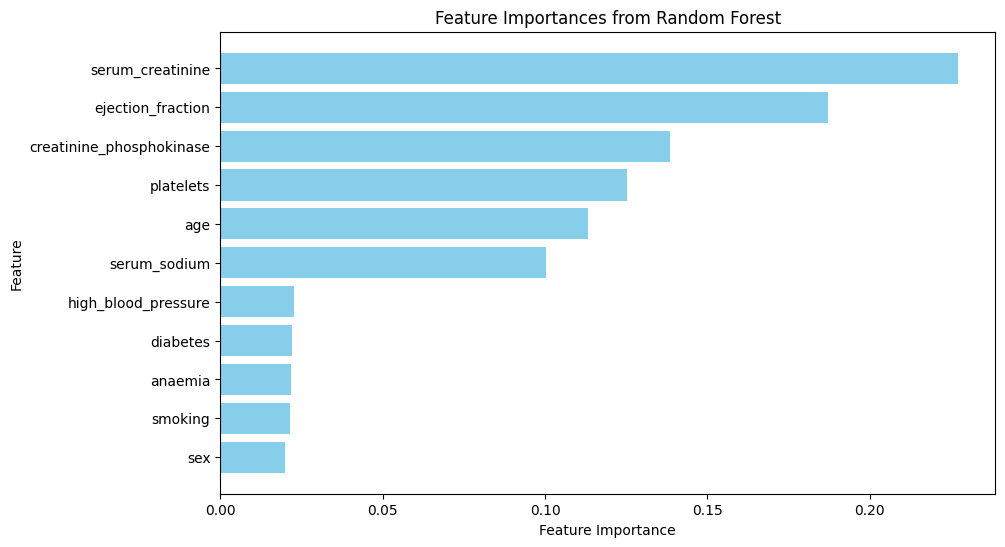

In [53]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# Train a Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Extract feature importances
feature_importances = model.feature_importances_

# Create a DataFrame for better visualization
feature_importances_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort features by importance
feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False)

# Print feature importances
print(feature_importances_df)

# Plot feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_importances_df['Feature'], feature_importances_df['Importance'], color='skyblue')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importances from Random Forest')
plt.gca().invert_yaxis()
plt.show()

## Does Feature Selection Actually Help?

Now we test whether selecting only the top features improves model performance.

**Experiment:**
- Model trained on **top 2 features** (selected by Lasso: `ejection_fraction` + `serum_creatinine`)
- Model trained on **all 11 features** (no selection)

**What to look for:** If the selected features give equal or better F1/accuracy with fewer inputs, the selection was successful. This is especially important on small datasets where irrelevant features hurt generalization.

In [54]:
# train on top 2 features: 
selected_features = feature_names[abs(B2) >= 0.05]
print(f'features used are: {selected_features}')

X_train_top_features = X_train.loc[:,selected_features]
X_test_top_features = X_test.loc[:,selected_features]

# Random Forest model 
# Train a Random Forest model
model = RandomForestClassifier()
model.fit(X_train_top_features, y_train)
preds = model.predict(X_test_top_features)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print("Accuracy:", accuracy_score(y_test, preds))
print("Precision:", precision_score(y_test, preds))
print("Recall:", recall_score(y_test, preds))
print("F1-Score:", f1_score(y_test, preds))


features used are: Index(['ejection_fraction', 'serum_creatinine'], dtype='str')
Accuracy: 0.7777777777777778
Precision: 0.6956521739130435
Recall: 0.5517241379310345
F1-Score: 0.6153846153846154


In [55]:
#model with no feature selection 

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

preds = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))
print("Precision:", precision_score(y_test, preds))
print("Recall:", recall_score(y_test, preds))
print("F1-Score:", f1_score(y_test, preds))

Accuracy: 0.7666666666666667
Precision: 0.6666666666666666
Recall: 0.5517241379310345
F1-Score: 0.6037735849056604


# Kaggle Competition 

## Kaggle Challenge Instructions

Use everything you have learned in the previous weeks to develop a new algorithm that achieves the highest possible test accuracy.

Perform the train–test split exactly as specified below. Do not modify the provided cell.

Use the training set only for:

Feature selection

Hyperparameter optimization

Cross-validation

The test set must be used only for final evaluation of your algorithm, and you must report the test accuracy.

Performing any steps on the test set other than final evaluation will be considered cheating and will result in disqualification from the challenge.


In [56]:
#Don't modify this cell
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# RESET INDEX
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

scaler = StandardScaler()
X_train = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=feature_names
)

X_test = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_names
)